# Visão geral das vendas — base train.csv

Panorama das vendas de 2015 a 2018 nos Estados Unidos para a gestão.
Vamos responder uma pergunta por vez, com tabelas curtas e gráficos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.display.float_format = '{:,.0f}'.format

In [2]:
COR_PRIMARIA = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE = "#E69F00"
COR_EIXO = "#B0B7C3"
COR_TEXTO = "#334155"
PALETA = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "font.size": 12,
    "text.color": COR_TEXTO,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.titlecolor": COR_TEXTO,
    "axes.labelcolor": COR_EIXO,
    "axes.edgecolor": COR_EIXO,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.color": COR_EIXO,
    "ytick.color": COR_EIXO,
    "axes.prop_cycle": plt.cycler(color=PALETA),
})

## Os dados foram lidos corretamente?
Vamos carregar o arquivo e conferir se colunas e números saíram legíveis.

In [3]:
df = pd.read_csv("../../.data/train.csv")
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,262
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",732
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,15
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,958
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22


**Resultado:** leitura limpa, separador por vírgula e 9.800 linhas por 18 colunas. Rótulos legíveis e vendas como número. Podemos seguir.

## O que tem dentro da base? Falta algum dado?
Vamos ver os tipos de cada coluna e onde há espaços vazios.

In [4]:
df.dtypes.to_frame("tipo")

,tipo
Row ID,int64
Order ID,str
Order Date,str
Ship Date,str
Ship Mode,str
Customer ID,str
Customer Name,str
Segment,str
Country,str
City,str


In [5]:
df.isna().sum().to_frame("faltantes")

,faltantes
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


**Resultado:** só o CEP tem 11 vazios, todos de Burlington em Vermont. Nada que trave a análise. País é sempre Estados Unidos, então não ajuda a separar nada.

## Em que período estamos e qual o tamanho do negócio?
Vamos converter as datas e contar clientes, pedidos e produtos.

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [7]:
print(df["Order Date"].min(), "->", df["Order Date"].max())
print("clientes:", df["Customer ID"].nunique())
print("pedidos:", df["Order ID"].nunique())
print("produtos:", df["Product ID"].nunique())

2015-01-03 00:00:00 -> 2018-12-30 00:00:00
clientes: 793
pedidos: 4922
produtos: 1861


**Resultado:** 4 anos cheios, de jan/2015 a dez/2018, com 793 clientes em 4.922 pedidos e 1.861 produtos. Base grande o suficiente para comparar categorias e regiões.

## Quanto vale uma venda típica?
Vamos ver a distribuição dos valores por linha de pedido.

In [8]:
df["Sales"].describe().to_frame("valor")

,valor
count,"9,800"
mean,231
std,627
min,0
25%,17
50%,54
75%,211
max,"22,638"


**Resultado:** a venda do meio fica em torno de `US$ 54`, mas a média vai a `US$ 231` porque alguns itens passam de `US$ 22 mil`. Ou seja, poucos itens caros puxam o faturamento.

## O que gera mais receita: qual categoria?
Vamos somar o faturamento por categoria.

In [9]:
receita_cat = df.groupby("Category")["Sales"].sum().sort_values()
receita_cat.to_frame("receita")

,receita
Category,
Office Supplies,"705,422"
Furniture,"728,659"
Technology,"827,456"


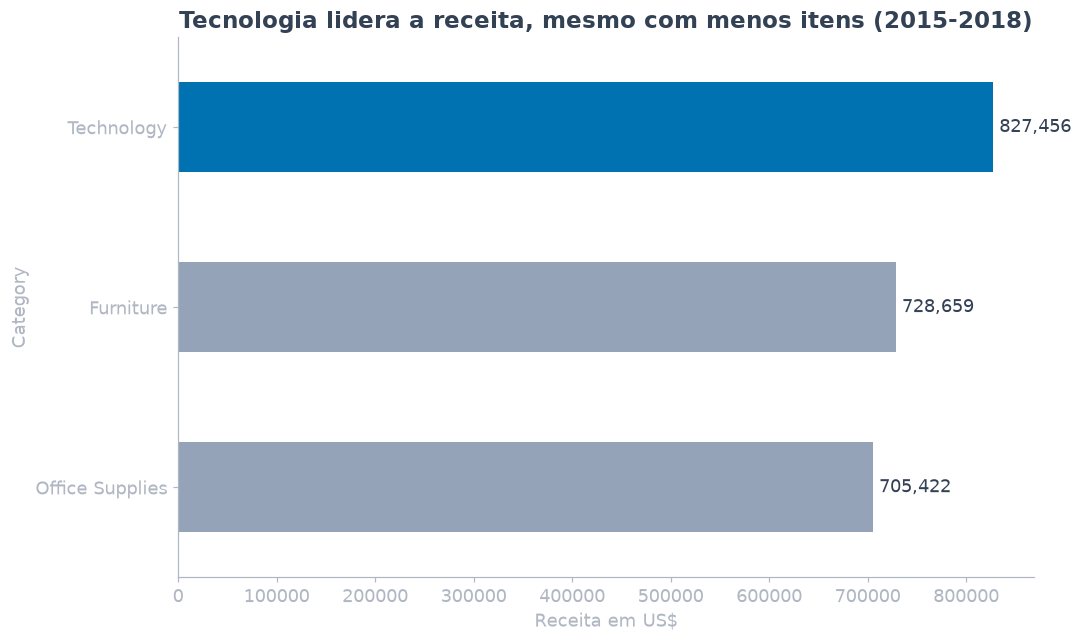

In [10]:
ax = receita_cat.plot.barh(color=[COR_SECUNDARIA, COR_SECUNDARIA, COR_PRIMARIA])
ax.set_title("Tecnologia lidera a receita, mesmo com menos itens (2015-2018)")
ax.set_xlabel("Receita em US$")
for i, v in enumerate(receita_cat.values):
    ax.text(v, i, f" {v:,.0f}", va="center", color=COR_TEXTO)
plt.tight_layout()
plt.show()

**Resultado:** Tecnologia vende menos itens e fatura mais. Material de escritório vende muito em quantidade, mas com tíquete baixo. O mix importa mais que o volume.

## Quais subcategorias pesam mais no bolso?
Vamos abrir as 10 subcategorias de maior receita.

In [11]:
receita_sub = df.groupby("Sub-Category")["Sales"].sum()
receita_sub.sort_values(ascending=False).head(10).to_frame("receita")

,receita
Sub-Category,
Phones,"327,782"
Chairs,"322,823"
Storage,"219,343"
Tables,"202,811"
Binders,"200,029"
Machines,"189,239"
Accessories,"164,187"
Copiers,"146,248"
Bookcases,"113,813"


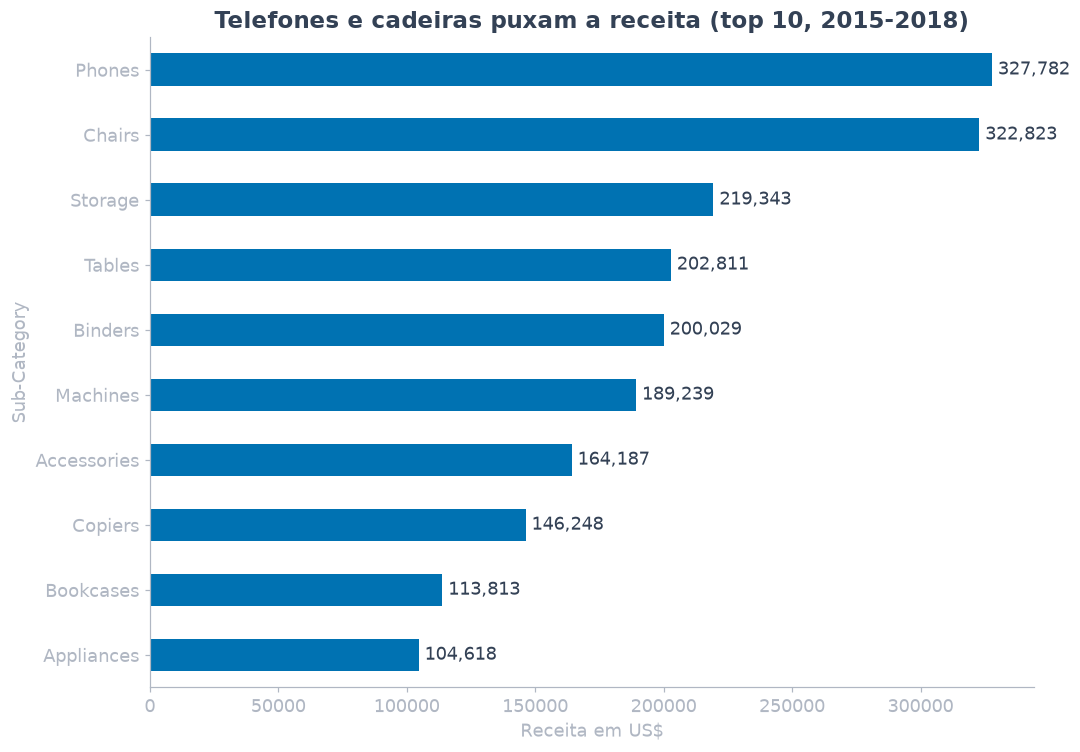

In [12]:
top_sub = receita_sub.sort_values(ascending=False).head(10).sort_values()
ax = top_sub.plot.barh(color=COR_PRIMARIA, figsize=(10, 7))
ax.set_title("Telefones e cadeiras puxam a receita (top 10, 2015-2018)")
ax.set_xlabel("Receita em US$")
for i, v in enumerate(top_sub.values):
    ax.text(v, i, f" {v:,.0f}", va="center", color=COR_TEXTO)
plt.tight_layout()
plt.show()

**Resultado:** telefones, cadeiras e copiadoras concentram a receita. Pastas e papéis aparecem muito em quantidade, mas com valor menor por item.

## Para quem e onde vendemos mais?
Vamos comparar o faturamento por perfil de cliente e por região.

In [13]:
df.groupby("Segment")["Sales"].sum().sort_values().to_frame("receita")

,receita
Segment,
Home Office,"424,982"
Corporate,"688,494"
Consumer,"1,148,061"


In [14]:
df.groupby("Region")["Sales"].sum().sort_values().to_frame("receita")

,receita
Region,
South,"389,151"
Central,"492,647"
East,"669,519"
West,"710,220"


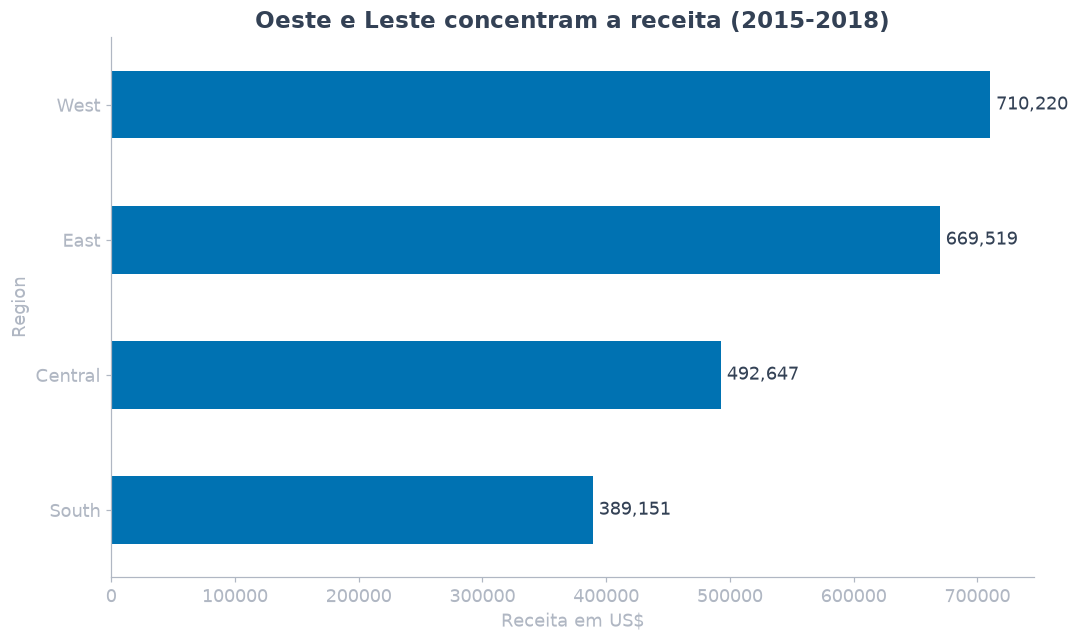

In [15]:
receita_reg = df.groupby("Region")["Sales"].sum().sort_values()
ax = receita_reg.plot.barh(color=COR_PRIMARIA)
ax.set_title("Oeste e Leste concentram a receita (2015-2018)")
ax.set_xlabel("Receita em US$")
for i, v in enumerate(receita_reg.values):
    ax.text(v, i, f" {v:,.0f}", va="center", color=COR_TEXTO)
plt.tight_layout()
plt.show()

**Resultado:** o consumidor final responde pela maior fatia, seguido do corporativo. Oeste e Leste lideram, Sul fica para trás — vale checar se é menor presença ou tíquete menor.

## Como as vendas evoluem de 2015 a 2018?
Vamos somar a receita por ano.

In [16]:
df["ano"] = df["Order Date"].dt.year
receita_ano = df.groupby("ano")["Sales"].sum()
receita_ano.to_frame("receita")

,receita
ano,
2015,"479,856"
2016,"459,436"
2017,"600,193"
2018,"722,052"


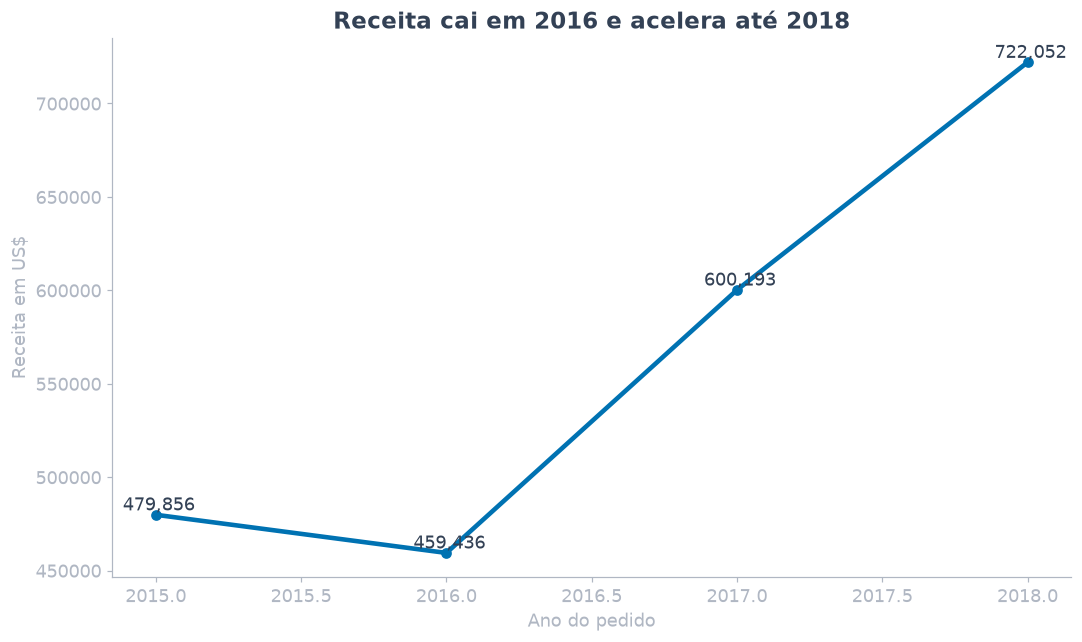

In [17]:
ax = receita_ano.plot(marker="o", linewidth=3, color=COR_PRIMARIA)
ax.set_title("Receita cai em 2016 e acelera até 2018")
ax.set_ylabel("Receita em US$")
ax.set_xlabel("Ano do pedido")
for x, y in zip(receita_ano.index, receita_ano.values):
    ax.text(x, y, f" {y:,.0f}", ha="center", va="bottom", color=COR_TEXTO)
plt.tight_layout()
plt.show()

**Resultado:** queda leve em 2016 e salto em 2017-2018. O negócio acelera no fim da série — entender o que mudou em 2017 ajuda a repetir o acerto.

## O prazo de entrega combina com a forma de envio?
Vamos medir os dias entre pedido e envio por modalidade.

In [18]:
df["prazo_dias"] = (df["Ship Date"] - df["Order Date"]).dt.days
df[["Ship Mode", "prazo_dias"]].head()

,Ship Mode,prazo_dias
0,Second Class,3
1,Second Class,3
2,Second Class,4
3,Standard Class,7
4,Standard Class,7


In [19]:
df.groupby("Ship Mode")["prazo_dias"].mean().sort_values().to_frame("prazo_medio_dias")

,prazo_medio_dias
Ship Mode,
Same Day,0
First Class,2
Second Class,3
Standard Class,5


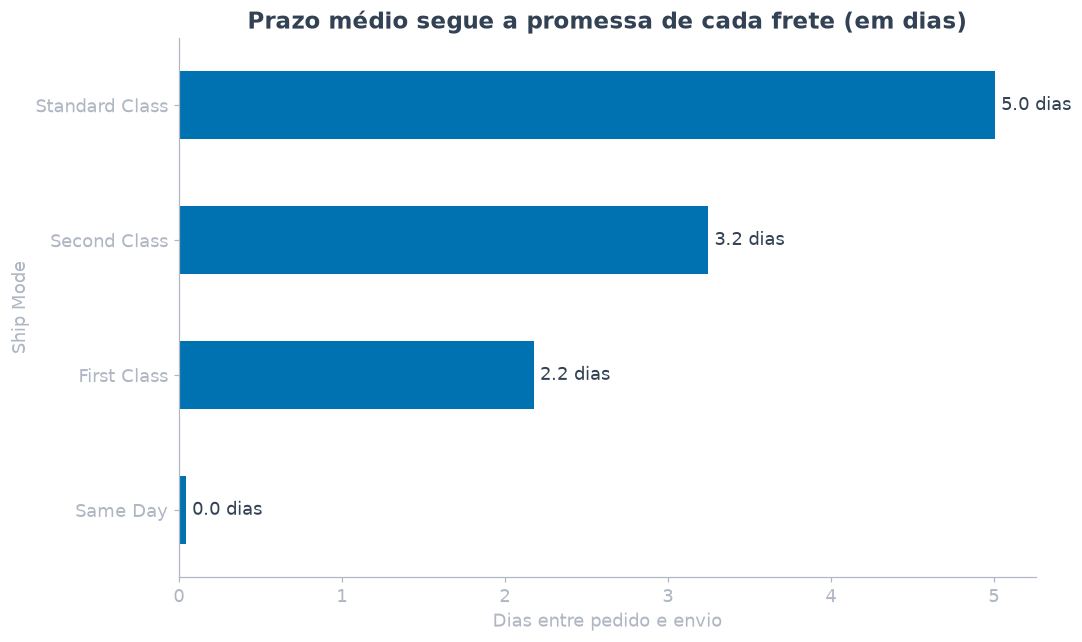

In [20]:
prazo = df.groupby("Ship Mode")["prazo_dias"].mean().sort_values()
ax = prazo.plot.barh(color=COR_PRIMARIA)
ax.set_title("Prazo médio segue a promessa de cada frete (em dias)")
ax.set_xlabel("Dias entre pedido e envio")
for i, v in enumerate(prazo.values):
    ax.text(v, i, f" {v:.1f} dias", va="center", color=COR_TEXTO)
plt.tight_layout()
plt.show()

**Resultado:** a operação cumpre o prometido: entrega no mesmo dia fica perto de zero, padrão fica em torno de 5 dias. Frete não parece gargalo.

## Conclusão — o que aprendemos?

**Achados:** negócio cai levemente em 2016 e acelera em 2017-2018. Tecnologia fatura mais com menos itens. Telefones, cadeiras e copiadoras puxam a receita. Consumidor final e regiões Oeste/Leste concentram vendas. Entrega cumpre o prazo por modalidade.

**Limites:** análise só com valor de venda, sem custo nem lucro. CEP com 11 vazios em Vermont. País único, sem comparação internacional.

**Próximas decisões:** checar margem por categoria, entender o salto de 2017 e investigar por que o Sul vende menos.